Leave-One-Subject-Out (LOSO) Cross-Validation

LOSO holds out all recordings from one subject per fold (6–7 recordings) and trains
from scratch on the remaining 31 subjects   
Mean LOSO BA is approx. fraction of unseen subjects correctly classified

Protocol (same inner_k=5 for all models):  
- Outer: `LeaveOneGroupOut` (one subject held out per fold) 
- Inner: `GroupKFold(k=5)` inside `GridSearchCV` (same grids as the original model notebooks)
- No information from the held-out subject enters hyperparameter selection at any point

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

os.makedirs('outputs', exist_ok=True)

PALETTE = {
    "PD":      "#E24B4A",
    "Healthy": "#378ADD",
    "SVM":     "#7F77DD",
    "HGB":     "#1D9E75",
    "LR":      "#BA7517",
    "RF":      "#B07FC8",
    "All":     "#D4537E",
    "JS":      "#639922",
}

plt.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "sans-serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})
sns.set_style("whitegrid")

## Load Data

Combine train + test so every subject participates in LOSO evaluation.

In [4]:
train_a = pd.read_csv('../data/train_a.csv')
test_a  = pd.read_csv('../data/test_a.csv')
train_b = pd.read_csv('../data/train_b.csv')
test_b  = pd.read_csv('../data/test_b.csv')

full_a = pd.concat([train_a, test_a], ignore_index=True)
full_b = pd.concat([train_b, test_b], ignore_index=True)

feature_cols = [c for c in full_a.columns if c not in ('name', 'status')]
JITTER_SHIMMER = [
    'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
    'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
    'MDVP:APQ', 'Shimmer:DDA',
]

# Group by subject: 'phon_R01_S05_1' → 'phon_R01_S05'
for df in [full_a, full_b]:
    df['subject'] = df['name'].str.rsplit('_', n=1).str[0]

print(f'Dataset A: {len(full_a)} recordings, {full_a["subject"].nunique()} subjects')
print(f'Dataset B: {len(full_b)} recordings, {full_b["subject"].nunique()} subjects')
print(f'Status distribution A: {full_a["status"].value_counts().sort_index().to_dict()}  (0=Healthy, 1=PD)')

Dataset A: 195 recordings, 32 subjects
Dataset B: 187 recordings, 32 subjects
Status distribution A: {0.0: 48, 1.0: 147}  (0=Healthy, 1=PD)


LogTransformer

Identical to `svm_classification.ipynb`, log-transforms the 18 Shapiro-Wilk-identified skewed features, fit on each training fold independently.

In [ ]:
SKEWED_FEATURES = ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'PPE', 'spread1', 'D2']


class LogTransformer(BaseEstimator, TransformerMixin):
    """Log-transform skewed features, fit on training fold only."""

    def __init__(self, skewed_cols, all_cols):
        self.skewed_cols = skewed_cols
        self.all_cols    = all_cols

    def fit(self, X, y=None):
        df = pd.DataFrame(X, columns=self.all_cols)
        self.mins_    = {c: df[c].min()             for c in self.skewed_cols}
        self.use_log_ = {c: bool((df[c] > 0).all()) for c in self.skewed_cols}
        return self

    def transform(self, X, y=None):
        df = pd.DataFrame(X, columns=self.all_cols).copy()
        for c in self.skewed_cols:
            if self.use_log_[c]:
                df[c] = np.log(df[c])
            else:
                df[c] = np.log1p(df[c] - self.mins_[c])
        return df.values

LOSO Evaluation Function

Outer loop: `LeaveOneGroupOut` (one subject per fold).  
Inner loop: `GroupKFold(k=5)` inside `GridSearchCV`, same protocol as the original model notebooks, now applied within each LOSO fold so no leakage occurs.

In [ ]:
def loso_evaluate(pipe, param_grid, X, y, groups,
                  inner_k=5, scoring='balanced_accuracy'):
    """
    Nested LOSO: outer = LeaveOneGroupOut, inner = GroupKFold(k=5) in GridSearchCV.

    Returns
    -------
    ba_scores : np.ndarray (per-fold balanced accuracy)
    f1_scores : np.ndarray (per-fold macro F1)
    """
    logo = LeaveOneGroupOut()
    ba_scores, f1_scores = [], []

    for train_idx, test_idx in logo.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        g_tr       = groups[train_idx]

        # Inner CV: also group-based to prevent leakage within the inner loop
        n_inner  = min(inner_k, len(np.unique(g_tr)))
        inner_cv = GroupKFold(n_splits=n_inner)

        gs = GridSearchCV(pipe, param_grid, cv=inner_cv,
                          scoring=scoring, n_jobs=-1, refit=True)
        gs.fit(X_tr, y_tr, groups=g_tr)

        y_pred = gs.predict(X_te)
        ba_scores.append(balanced_accuracy_score(y_te, y_pred))
        f1_scores.append(f1_score(y_te, y_pred, average='macro', zero_division=0))

    return np.array(ba_scores), np.array(f1_scores)

## Model Pipelines and Hyperparameter Grids

Exact same grids as the original model notebooks

In [7]:
# ── SVM (from svm_classification.ipynb) ──────────────────────────────────
def make_svm(feat_cols):
    skewed = [c for c in SKEWED_FEATURES if c in feat_cols]
    pipe = Pipeline([
        ('log',    LogTransformer(skewed_cols=skewed, all_cols=feat_cols)),
        ('scaler', StandardScaler()),
        ('svm',    SVC(kernel='rbf', class_weight='balanced', random_state=42)),
    ])
    grid = {
        'svm__C':     [0.1, 1, 10, 100],
        'svm__gamma': ['scale', 'auto'],
    }
    return pipe, grid


# ── Logistic Regression (from Logistic regression.ipynb) ──────────────────
def make_lr(feat_cols):
    skewed = [c for c in SKEWED_FEATURES if c in feat_cols]
    pipe = Pipeline([
        ('log',    LogTransformer(skewed_cols=skewed, all_cols=feat_cols)),
        ('scaler', StandardScaler()),
        ('lr',     LogisticRegression(penalty='l1', solver='liblinear',
                                      class_weight='balanced', random_state=42,
                                      max_iter=1000)),
    ])
    grid = {'lr__C': np.logspace(-3, 3, 10)}
    return pipe, grid


# ── HGB (from HGB_pipeline.ipynb) ─────────────────────────────────────────
def make_hgb():
    # No LogTransformer — HGB handles mixed scales natively
    # early_stopping reduces effective max_iter and speeds up fitting
    pipe = Pipeline([
        ('hgb', HistGradientBoostingClassifier(
            class_weight='balanced', random_state=42,
            early_stopping=True, validation_fraction=0.15, n_iter_no_change=20,
        )),
    ])
    grid = {
        'hgb__learning_rate':    [0.03, 0.05, 0.08, 0.1],
        'hgb__max_iter':         [100, 200, 300],
        'hgb__max_leaf_nodes':   [5, 10, 15, 20, 31],
        'hgb__l2_regularization':[0.0, 0.01, 0.1, 1.0],
        'hgb__min_samples_leaf': [5, 10, 20],
    }
    return pipe, grid


# ── Random Forest (from random_forest_complete.ipynb) ─────────────────────
def make_rf(feat_cols):
    skewed = [c for c in SKEWED_FEATURES if c in feat_cols]
    pipe = Pipeline([
        ('log',    LogTransformer(skewed_cols=skewed, all_cols=feat_cols)),
        ('scaler', StandardScaler()),
        ('rf',     RandomForestClassifier(class_weight='balanced', random_state=42)),
    ])
    grid = {
        'rf__n_estimators':     [100, 200],
        'rf__max_depth':        [None, 10, 20],
        'rf__min_samples_leaf': [1, 5],
    }
    return pipe, grid


print('Grid sizes (combos × 5 inner folds × 32 outer folds):')
import itertools
for name, g in [('SVM', {'C':[0.1,1,10,100],'gamma':['scale','auto']}),
                ('LR',  {'C': list(np.logspace(-3,3,10))}),
                ('HGB', {'lr':[0.03,0.05,0.08,0.1],'iter':[100,200,300],
                         'leaf':[5,10,15,20,31],'l2':[0.0,0.01,0.1,1.0],'ms':[5,10,20]}),
                ('RF',  {'n':[100,200],'d':[None,10,20],'ms':[1,5]})]:
    n = 1
    for v in g.values(): n *= len(v)
    print(f'  {name}: {n} combos × 5 × 32 = {n*5*32} total fits')

Grid sizes (combos × 5 inner folds × 32 outer folds):
  SVM: 8 combos × 5 × 32 = 1280 total fits
  LR: 10 combos × 5 × 32 = 1600 total fits
  HGB: 720 combos × 5 × 32 = 115200 total fits
  RF: 12 combos × 5 × 32 = 1920 total fits


## LOSO

Evaluates all 4 models on Dataset A and B, both feature sets.  
Results are saved to `outputs/loso_results.csv`, skips re-running if the file exists.

In [8]:
import os, time

OUT_CSV = 'outputs/loso_results.csv'

if os.path.exists(OUT_CSV):
    print(f'Found {OUT_CSV} — loading existing results. Delete file to re-run.')
    df_loso = pd.read_csv(OUT_CSV)
    display(df_loso)
else:
    datasets = {
        'A': full_a,
        'B': full_b,
    }
    feat_configs = {
        'All features':   feature_cols,
        'Jitter+Shimmer': JITTER_SHIMMER,
    }
    loso_rows = []
    t0 = time.time()

    for ds_key, df_full in datasets.items():
        y      = df_full['status'].values.astype(int)
        groups = df_full['subject'].values

        for feat_label, fc in feat_configs.items():
            X = df_full[fc].values

            for model_label, make_fn in [
                ('SVM', lambda: make_svm(fc)),
                ('LR',  lambda: make_lr(fc)),
                ('RF',  lambda: make_rf(fc)),
                ('HGB', lambda: make_hgb()),
            ]:
                print(f'[{model_label}] Dataset {ds_key} | {feat_label} ...', flush=True)
                t1 = time.time()
                pipe, grid = make_fn()
                ba, f1 = loso_evaluate(pipe, grid, X, y, groups)
                elapsed = time.time() - t1
                print(f'  → BA = {ba.mean():.3f} ± {ba.std():.3f}  '
                      f'F1 = {f1.mean():.3f} ± {f1.std():.3f}  [{elapsed/60:.1f} min]')
                loso_rows.append({
                    'Model':   model_label,
                    'Dataset': ds_key,
                    'Features': feat_label,
                    'BA_mean': round(ba.mean(), 3),
                    'BA_std':  round(ba.std(),  3),
                    'F1_mean': round(f1.mean(), 3),
                    'F1_std':  round(f1.std(),  3),
                    'n_folds': len(ba),
                })

    df_loso = pd.DataFrame(loso_rows)
    df_loso.to_csv(OUT_CSV, index=False)
    print(f'\nTotal runtime: {(time.time()-t0)/60:.1f} min')
    print(f'Saved: {OUT_CSV}')
    display(df_loso)

[SVM] Dataset A | All features ...
  → BA = 0.714 ± 0.382  F1 = 0.625 ± 0.401  [0.1 min]
[LR] Dataset A | All features ...
  → BA = 0.700 ± 0.360  F1 = 0.579 ± 0.375  [0.1 min]
[RF] Dataset A | All features ...
  → BA = 0.771 ± 0.381  F1 = 0.707 ± 0.402  [0.5 min]
[HGB] Dataset A | All features ...
  → BA = 0.730 ± 0.358  F1 = 0.637 ± 0.385  [11.3 min]
[SVM] Dataset A | Jitter+Shimmer ...
  → BA = 0.624 ± 0.409  F1 = 0.554 ± 0.416  [0.0 min]
[LR] Dataset A | Jitter+Shimmer ...
  → BA = 0.666 ± 0.385  F1 = 0.610 ± 0.404  [0.1 min]
[RF] Dataset A | Jitter+Shimmer ...
  → BA = 0.714 ± 0.376  F1 = 0.627 ± 0.396  [0.6 min]
[HGB] Dataset A | Jitter+Shimmer ...
  → BA = 0.653 ± 0.359  F1 = 0.562 ± 0.384  [7.1 min]
[SVM] Dataset B | All features ...
  → BA = 0.712 ± 0.356  F1 = 0.583 ± 0.374  [0.0 min]
[LR] Dataset B | All features ...
  → BA = 0.673 ± 0.381  F1 = 0.564 ± 0.388  [0.2 min]
[RF] Dataset B | All features ...
  → BA = 0.755 ± 0.386  F1 = 0.701 ± 0.406  [0.6 min]
[HGB] Dataset B | 

,Model,Dataset,Features,BA_mean,BA_std,F1_mean,F1_std,n_folds
0,SVM,A,All features,0.714,0.382,0.625,0.401,32
1,LR,A,All features,0.700,0.360,0.579,0.375,32
2,RF,A,All features,0.771,0.381,0.707,0.402,32
3,HGB,A,All features,0.730,0.358,0.637,0.385,32
4,SVM,A,Jitter+Shimmer,0.624,0.409,0.554,0.416,32
5,LR,A,Jitter+Shimmer,0.666,0.385,0.610,0.404,32
6,RF,A,Jitter+Shimmer,0.714,0.376,0.627,0.396,32
7,HGB,A,Jitter+Shimmer,0.653,0.359,0.562,0.384,32
8,SVM,B,All features,0.712,0.356,0.583,0.374,32
9,LR,B,All features,0.673,0.381,0.564,0.388,32


## Results Table

In [9]:
df_loso = pd.read_csv('outputs/loso_results.csv')

df_loso['BA'] = df_loso.apply(lambda r: f"{r.BA_mean:.3f} ± {r.BA_std:.3f}", axis=1)
df_loso['F1'] = df_loso.apply(lambda r: f"{r.F1_mean:.3f} ± {r.F1_std:.3f}", axis=1)

pivot = df_loso.pivot_table(
    index=['Model', 'Dataset'],
    columns='Features',
    values=['BA', 'F1'],
    aggfunc='first'
)
display(pivot)

BA                            F1               
Features        All features Jitter+Shimmer   All features Jitter+Shimmer
Model Dataset                                                            
HGB   A        0.730 ± 0.358  0.653 ± 0.359  0.637 ± 0.385  0.562 ± 0.384
      B        0.746 ± 0.354  0.584 ± 0.397  0.676 ± 0.385  0.509 ± 0.403
LR    A        0.700 ± 0.360  0.666 ± 0.385  0.579 ± 0.375  0.610 ± 0.404
      B        0.673 ± 0.381  0.648 ± 0.385  0.564 ± 0.388  0.554 ± 0.392
RF    A        0.771 ± 0.381  0.714 ± 0.376  0.707 ± 0.402  0.627 ± 0.396
      B        0.755 ± 0.386  0.685 ± 0.380  0.701 ± 0.406  0.600 ± 0.399
SVM   A        0.714 ± 0.382  0.624 ± 0.409  0.625 ± 0.401  0.554 ± 0.416
      B        0.712 ± 0.356  0.641 ± 0.388  0.583 ± 0.374  0.550 ± 0.396

## Visualisation

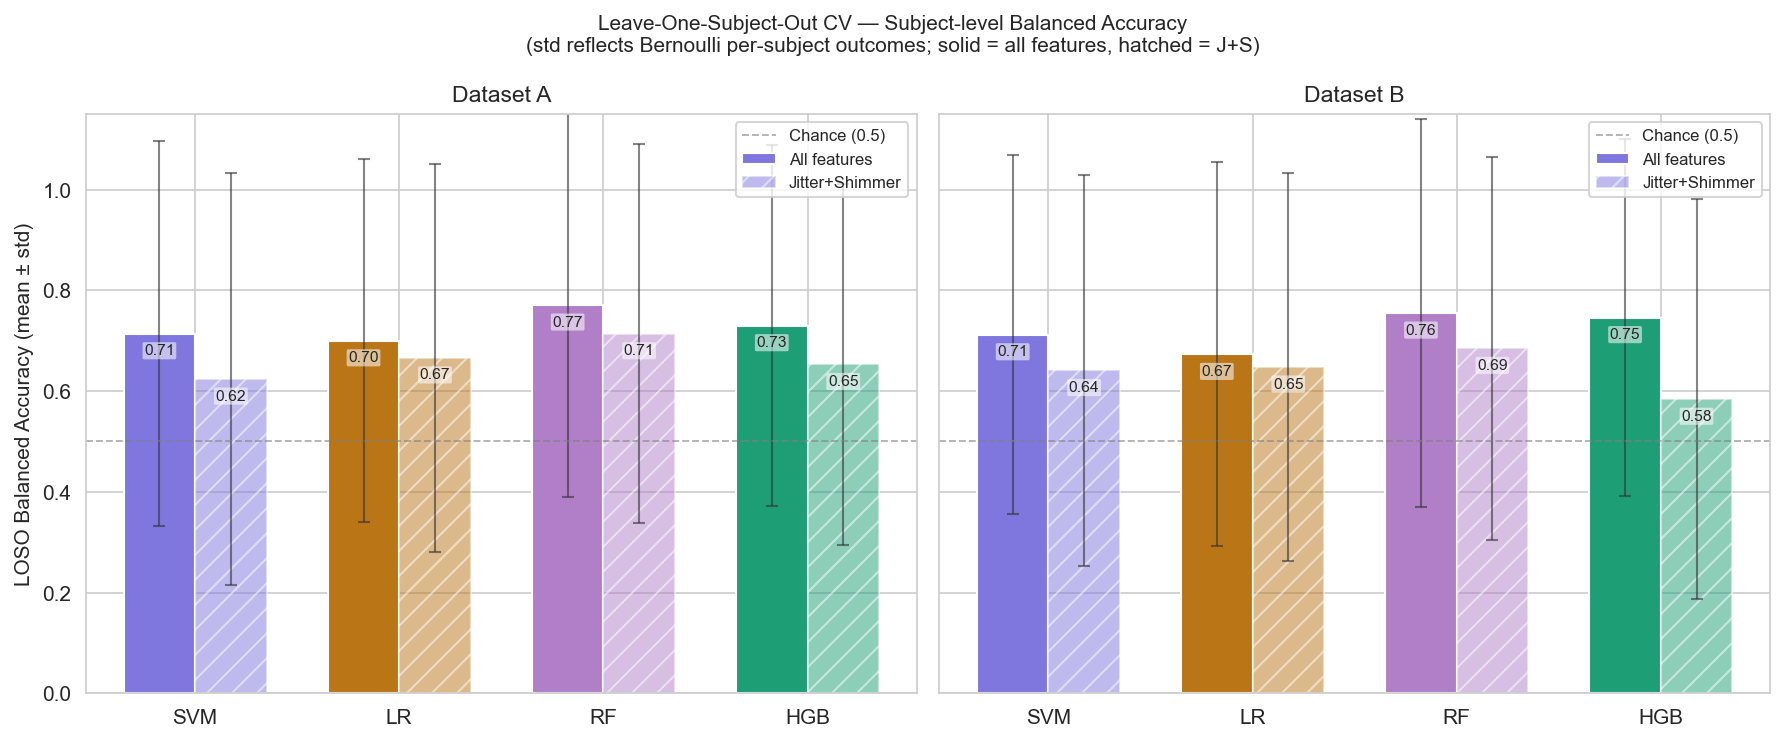

Saved: outputs/loso_results.png


In [4]:
df_loso = pd.read_csv('outputs/loso_results.csv')

model_order = ['SVM', 'LR', 'RF', 'HGB']
feat_order  = ['All features', 'Jitter+Shimmer']
feat_alpha  = {'All features': 1.0, 'Jitter+Shimmer': 0.5}
feat_hatch  = {'All features': '',  'Jitter+Shimmer': '//'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
x     = np.arange(len(model_order))
width = 0.35

for ax, ds_key in zip(axes, ['A', 'B']):
    df_ds = df_loso[df_loso['Dataset'] == ds_key]

    for i, feat in enumerate(feat_order):
        df_f   = df_ds[df_ds['Features'] == feat].set_index('Model')
        means  = [df_f.loc[m, 'BA_mean'] if m in df_f.index else 0 for m in model_order]
        stds   = [df_f.loc[m, 'BA_std']  if m in df_f.index else 0 for m in model_order]
        colors = [PALETTE[m] for m in model_order]
        offset = (i - 0.5) * width

        bars = ax.bar(x + offset, means, width,
                      yerr=stds, capsize=3,
                      error_kw=dict(elinewidth=1.0, ecolor='#333333', alpha=0.6),
                      color=colors, alpha=feat_alpha[feat],
                      hatch=feat_hatch[feat], edgecolor='white', label=feat)
        for bar, mean in zip(bars, means):
            if mean > 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() - 0.02,
                        f'{mean:.2f}', ha='center', va='top', fontsize=7.5,
                        bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.55, ec='none'))

    ax.axhline(0.5, color='grey', linestyle='--', lw=0.9, alpha=0.6, label='Chance (0.5)')
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.set_title(f'Dataset {ds_key}', fontsize=11)
    ax.set_ylabel('LOSO Balanced Accuracy (mean ± std)' if ds_key == 'A' else '')
    ax.legend(fontsize=8, loc = 'upper right')

fig.suptitle(
    'Leave-One-Subject-Out CV — Subject-level Balanced Accuracy\n'
    '(std reflects Bernoulli per-subject outcomes; solid = all features, hatched = J+S)',
    fontsize=10
)
plt.tight_layout()
plt.savefig('outputs/loso_results.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: outputs/loso_results.png')
